In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm

import imageio
import os
import shutil

# Datasets

In [6]:
edges = np.loadtxt("../Data/CancerEvo/transitions_small.txt").astype(int)
state_map  = np.loadtxt("../Data/CancerEvo/state_map_small.txt", dtype=str, delimiter=",")
state_map[0] = state_map[0][1:]
state_map[-1] = state_map[-1][:-1]

In [7]:
edges_df = pd.DataFrame({"from":edges[:,0]-1,"to":edges[:,1]-1,"freq":edges[:,2]})

In [8]:
def compute_mean(list_s):
    digits = np.array([[int(char) for char in s] for s in list_s])
    return np.mean(digits)

def compute_sum(list_s):
    digits = np.array([[int(char) for char in s] for s in list_s])
    return np.sum(digits)

def dist_pert(list_s):
    muts = np.concatenate(np.array([[int(char) for char in s] for s in list_s]))
    if len(muts)==16:
        return np.sum(muts-[1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0])
    else:
        return 20

In [9]:
sm_keys = np.array([sm.split(":")[0][1:-1].split("+") for sm in state_map])
sm_vals = [sm.split(":")[1][:] for sm in state_map]
state_df = pd.DataFrame({"idx":np.array(sm_vals).astype(int)-1, "type":sm_keys[:,0], "mut":sm_keys[:,1]})
state_df["nchr"] = state_df["type"].map(lambda x: len(x.split("/")))
state_df["ngenes"] = state_df["type"].map(lambda x: compute_sum(x.split("/")))
state_df["meanmut"] = state_df["mut"].map(lambda x: compute_mean(x.split("/")))
state_df["distpert"] = state_df["mut"].map(lambda x: dist_pert(x.split("/")))
state_df = state_df.sort_values("idx")
state_df = state_df.reset_index(drop=True)
state_df

,idx,type,mut,nchr,ngenes,meanmut,distpert
0,0,11111111/11111111,10101000/11001111,2,16,0.5625,7
1,1,11111111/11111111,11111111/01010100,2,16,0.6875,9
2,2,11111111/11111111,10111100/11111011,2,16,0.7500,10
3,3,11111111/11111111,11110101/11011100,2,16,0.6875,9
4,4,11111111/11111111,11000101/11110010,2,16,0.5625,7
...,...,...,...,...,...,...,...
4738,4738,11111111/11111111,10111001/01011101,2,16,0.6250,8
4739,4739,11111111/11111111,10110111/11010010,2,16,0.6250,8
4740,4740,11111111/11111111,11111111/01100001,2,16,0.6875,9
4741,4741,66666,11111,1,30,1.0000,20


In [81]:
def hk_sum(vec):
    vv = vec.sum(axis=0)
    if np.any(vv==2):
        return 3
    else:
        return sum(vv==1)
def t_sum(vec):
    if np.sum(vec)==0:
        return 0
    elif np.sum(vec)==1:
        return 1
    elif np.sum(vec.sum(axis=0)==1)==2:
        return 2
    elif np.sum(vec)==3:
        return 4
    elif sum(vec.sum(axis=0)==2)==1:
        return 3
    elif np.sum(vec)==4:
        return 5

In [105]:
def mapping_collapse(vve):
    if vve[0].size==8:
        cats = [[0,1],[2,3],[4,5],[6,7]]
        compr_state = []
        compr_state.append(sum(vve[:, cats[0]].sum(axis=0)>0))
        compr_state.append(sum(vve[:, cats[1]].sum(axis=0)>0))
        compr_state.append(t_sum(vve[:, cats[2]]))
        compr_state.append(hk_sum(vve[:, cats[3]]))
        return np.array(compr_state)
    else:
        return np.array([6,6,6,6])

In [128]:
collapsed = [np.array([[int(a) for a in vec] for vec in mmm.split("/")]) for mmm in state_df['mut']]
collapsed = np.array([("").join(mapping_collapse(vv).astype(str)) for vv in collapsed])
un_col = np.unique(collapsed, axis=0)
map_collapsed = {v:k for k,v in zip(np.arange(len(un_col)), un_col)}

In [133]:
idx_col_map = {k:v for k,v in zip(state_df['idx'], pd.Series(collapsed).map(map_collapsed))}

In [183]:
3*3*6*4

216

# Network definition

In [10]:
def get_state(idxs, df=state_df):
    if isinstance(idxs, int):
        return df[df['idx']==idxs]
    # Check if the input is a list
    elif isinstance(idxs, (list, np.ndarray)):
        return df[np.isin(df['idx'], idxs)]
    else:
        return "Input is neither a number nor a list."

## Complete net

In [11]:
ss0 = state_df[state_df["mut"] == "00000000/00000000"]
wt_state = ss0[ss0["type"] == "11111111/11111111"]['idx'].iloc[0]
dead_state = state_df[state_df["type"]=="66666"]['idx'].iloc[0]
ss0_pert = state_df[state_df["mut"] == "10100000/00000000"]
pert_state = ss0_pert[ss0_pert["type"] == "11111111/11111111"]['idx'].iloc[0]

In [46]:
edge_list = edges_df[["from","to","freq"]].values

g = Graph(directed=True)

g.ep['w'] = g.new_edge_property("int")
g.add_edge_list(edge_list, eprops=[g.ep['w']])
nchr = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        nchr[i]=state_df[state_df["idx"]==i]['nchr'].values[0]
g.vp['nchr'] = g.new_vertex_property("int", vals=nchr)

ng = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        ng[i]=state_df[state_df["idx"]==i]['ngenes'].values[0]
g.vp['ng'] = g.new_vertex_property("int", vals=ng)

avg_mut = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        avg_mut[i]=state_df[state_df["idx"]==i]['meanmut'].values[0]
g.vp['avgmut'] = g.new_vertex_property("float", vals=avg_mut)
#remove_self_loops(g)
g

<Graph object, directed, with 4743 vertices and 16393 edges, 3 internal vertex properties, 1 internal edge property, at 0x7fc002e4dd10>

### Remove dead state

In [47]:
g_noSL = g.copy()
remove_self_loops(g_noSL)
g_noD = g.copy()
g_noD.remove_vertex(dead_state)

In [49]:
g_noD

<Graph object, directed, with 4742 vertices and 11749 edges, 3 internal vertex properties, 1 internal edge property, at 0x7fc002e4d1d0>

### Plot Graph

Analysis of the pagerank, as a proxy of the probability of being in a given node. Thanks to the teleportation effects avoids the problems with the walker being trapped in nodes with no outgoing edges.

In [ ]:
pr = pagerank(g, weight=g.ep['w'], damping=0.99)
state_df['pr'] = state_df['idx'].map(lambda x: pr.a[x])

In [ ]:
state_df_sort = state_df.copy()
state_df_sort.sort_values('pr', ascending=False).head(30)

,idx,type,mut,nchr,ngenes,meanmut,distpert,pr
4741,4741,66666,11111,1,30,1.0000,20,0.051624
2901,2901,11111111/11111111,10111101/10010010,2,16,0.5625,7,0.002304
4233,4233,11111111/11111111,11111110/01011101,2,16,0.7500,10,0.001431
3394,3394,11111111/11111111,10111111/10010100,2,16,0.6250,8,0.001371
3165,3165,11111111/11111111,10111101/10010100,2,16,0.5625,7,0.001325
4503,4503,11111111/11111111,11100110/01011101,2,16,0.6250,8,0.001029
1541,1541,11111111/11111111,10111001/11100110,2,16,0.6250,8,0.000969
133,133,11111111/11111111,11111110/10001100,2,16,0.6250,8,0.000942
2018,2018,11111111/11111111,10111101/11001100,2,16,0.6250,8,0.000905
1792,1792,11111111/11111111,10111101/11000010,2,16,0.5625,7,0.000825


In [ ]:
in_deg = g.degree_property_map("in").a
out_deg = g.degree_property_map("out").a

vsize = g.new_vertex_property("float", vals=np.log(in_deg+1)*10)
#vsize = g.new_vertex_property("float", vals = np.exp(g.vp['ng'].a*0.05))
vsize.a[wt_state] = 40
#vsize.a[dead_state] = 25
vsize.a[pert_state] = 25

v_color = g.new_vertex_property("vector<double>", vals=[cm.gray_r(s)[:3] for s in g.vp['avgmut'].a])
#v_color[g.vertex(dead_state)] = [1,0,0]
#v_color[g.vertex(wt_state)] = [1,0,0]
v_color[g.vertex(pert_state)] = [1,0,0]

esize = g.new_edge_property("float", vals=np.log(g.ep['w'].a+1)*0.5)

In [ ]:
g.remove_vertex(dead_state)

In [ ]:
#pos = sfdp_layout(g)
#pos = random_layout(g)
#pos = arf_layout(g)
pos = radial_tree_layout(g, root=g.vertex(pert_state))
#pos = fruchterman_reingold_layout(g, r=2)

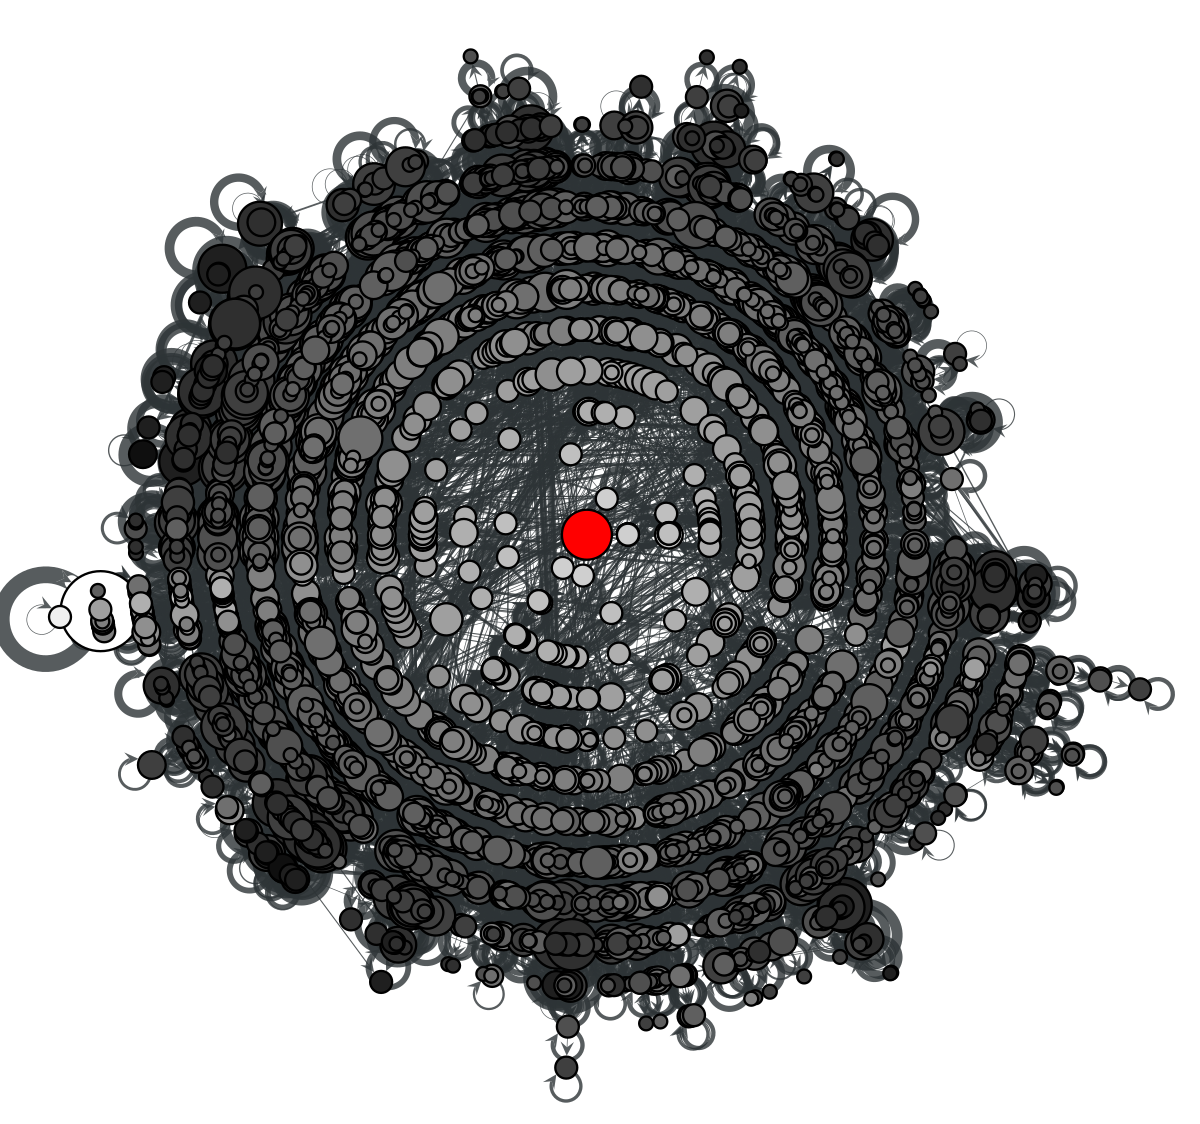

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fddc5829950, at 0x7fddc09dc2f0>

In [ ]:
graph_draw(g, pos=pos, 
           vertex_size=vsize, 
           vertex_fill_color=v_color, vertex_color="k",# vertex_text="ciao",# vertex_font_size=10,
           edge_pen_width=esize, edge_marker_size=7, 
           bg_color="w")#, output="images/graph_example.png")

## Collapsed net

In [164]:
edges_coll = edges_df.copy()
edges_coll['from'] = edges_coll['from'].map(idx_col_map)
edges_coll['to'] = edges_coll['to'].map(idx_col_map)
edges_coll = edges_coll.groupby(['from', 'to'], as_index=False)['freq'].sum()

In [182]:
edge_list = edges_coll[["from","to","freq"]].values

g_coll = Graph(directed=True)

g_coll.ep['w'] = g_coll.new_edge_property("int")
g_coll.add_edge_list(edge_list, eprops=[g_coll.ep['w']])

g_coll.remove_vertex(97)
g_coll

<Graph object, directed, with 97 vertices and 317 edges, 1 internal edge property, at 0x70cd2b6b57d0>

In [177]:
in_deg = g_coll.degree_property_map("in").a
out_deg = g_coll.degree_property_map("out").a

vsize = g_coll.new_vertex_property("float", vals=np.log(in_deg+1)*10)
#vsize = g.new_vertex_property("float", vals = np.exp(g.vp['ng'].a*0.05))
vsize.a[0] = 40
#vsize.a[dead_state] = 25
#vsize.a[pert_state] = 25

#v_color = g_coll.new_vertex_property("vector<double>", vals=[cm.gray_r(s)[:3] for s in g_.vp['avgmut'].a])
#v_color[g.vertex(dead_state)] = [1,0,0]
#v_color[g.vertex(wt_state)] = [1,0,0]
#v_color[g.vertex(pert_state)] = [1,0,0]

esize = g_coll.new_edge_property("float", vals=np.log(g_coll.ep['w'].a+2)*0.5)

In [178]:
pos = arf_layout(g_coll)

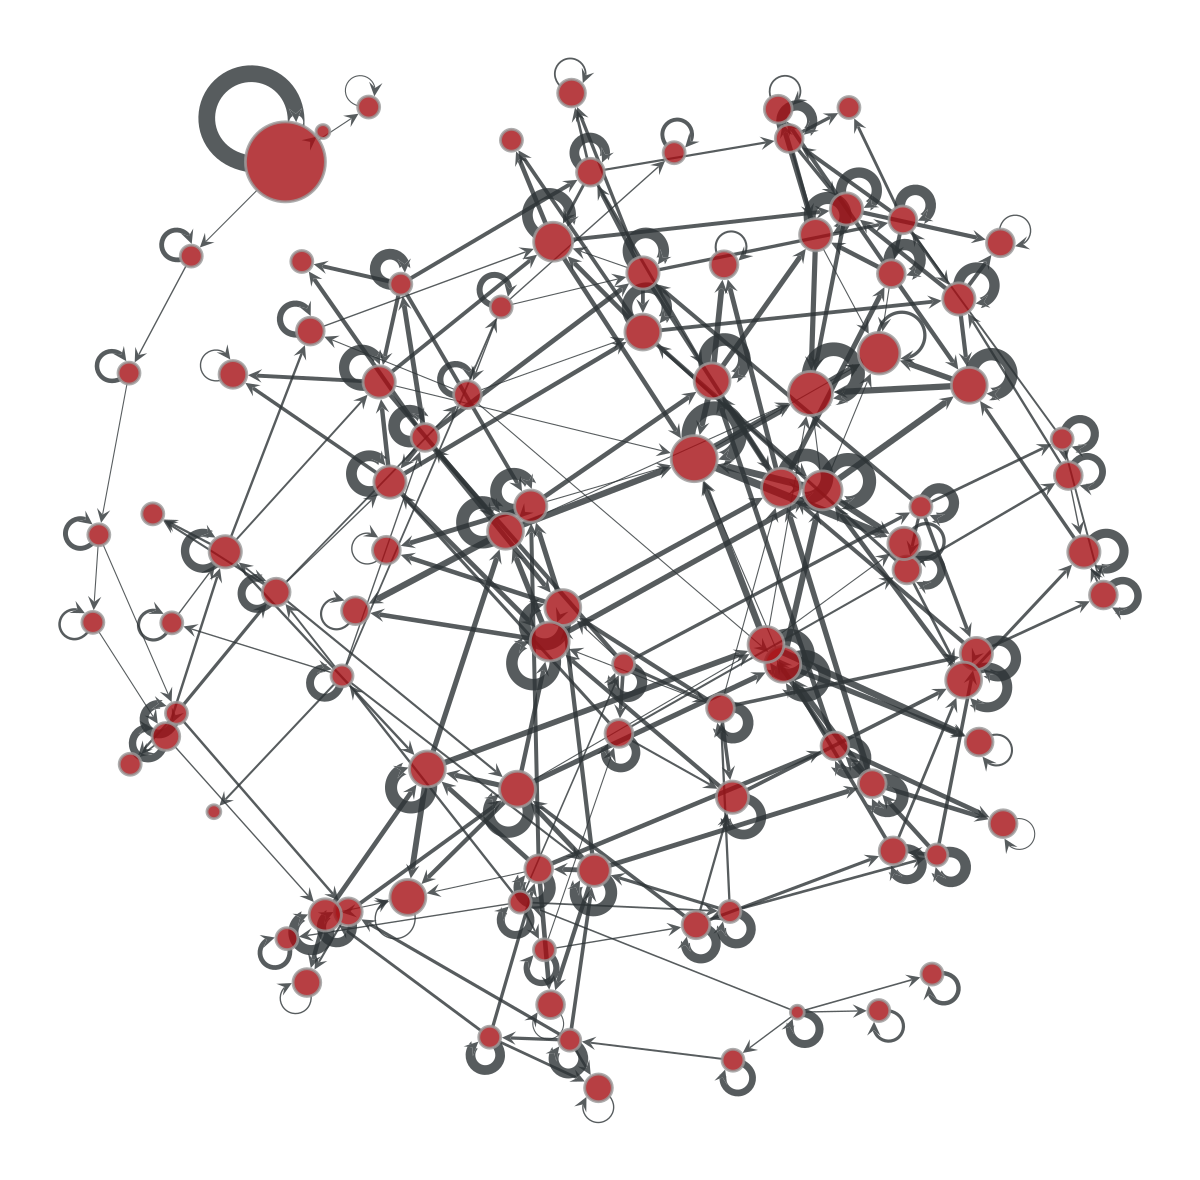

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x70cd29a50d50, at 0x70cd2ba29bd0>

In [179]:
graph_draw(g_coll, pos=pos, 
           vertex_size=vsize, 
           #vertex_fill_color=v_color, vertex_color="k",# vertex_text="ciao",# vertex_font_size=10,
           edge_pen_width=esize, edge_marker_size=7, 
           bg_color="w")#, output="images/graph_example.png")

# Analysis

## Entropy

In [ ]:
def entropy(G,tau):
    Ls = np.array(np.sort(laplacian(G).todense()).flatten())[0]
    Z = np.sum(np.exp(-tau*Ls))
    p = np.exp(-tau*Ls)/Z
    #p=np.delete(p,np.where(p<10**-8))
    S = np.sum( -p * np.log2(p) )
    return S

In [ ]:
density, density_noSL, density_noD = [], [], []
x = np.logspace(0,1.8,20)
for ti in tqdm(x):
    density.append(entropy(g, ti))
    density_noSL.append(entropy(g_noSL, ti))
    density_noD.append(entropy(g_noD, ti))

/tmp/ipykernel_163741/1412824296.py:6: RuntimeWarning: divide by zero encountered in log2
  S = np.sum( -p * np.log2(p) )
/tmp/ipykernel_163741/1412824296.py:6: RuntimeWarning: invalid value encountered in multiply
  S = np.sum( -p * np.log2(p) )
100%|███████████████████████████████████████████| 20/20 [00:36<00:00,  1.82s/it]


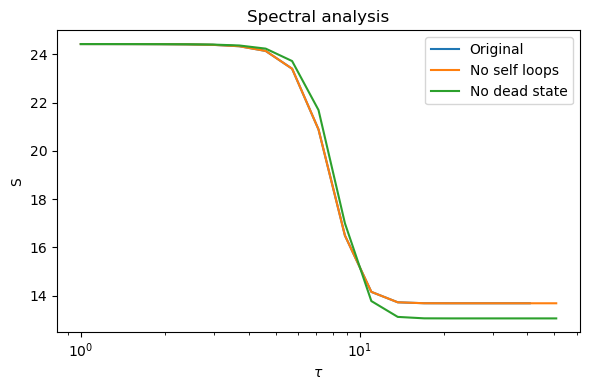

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(x, np.array(density), label="Original")
plt.plot(x, density_noSL, label="No self loops")
plt.plot(x, density_noD, label="No dead state")
plt.xlabel(r"$\tau$")
plt.ylabel("S")
plt.xscale("log")
plt.title("Spectral analysis")
plt.legend()
plt.tight_layout()


## Distribution genes/chromosomes

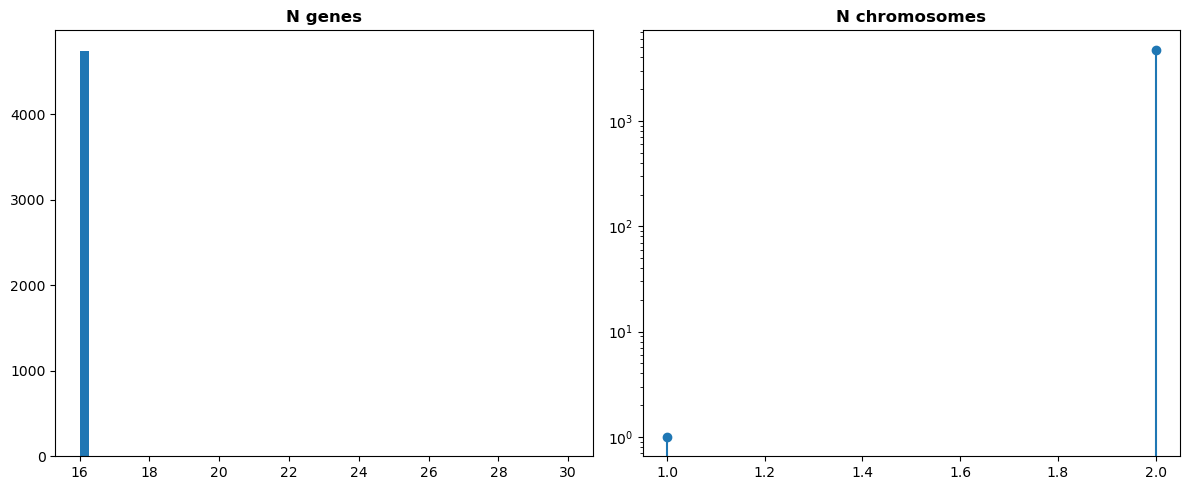

In [22]:
plt.subplots(1,2,figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(state_df["ngenes"], bins=50)
plt.title("N genes", fontweight="bold")
plt.subplot(1,2,2)
cnts = np.unique(state_df["nchr"],return_counts=True)
plt.stem(cnts[0], cnts[1])
plt.yscale("log")
plt.title("N chromosomes", fontweight="bold")
plt.tight_layout()

## Subgraphs

In [25]:
pert_state

np.int64(517)

In [27]:
get_state(g.get_all_neighbors(pert_state))

,idx,type,mut,nchr,ngenes,meanmut,pr
185,185,11111111/11111111,10110000/00000000,2,16,0.1875,0.000276
500,500,11111111/11111111,10100000/00100000,2,16,0.1875,0.000266
517,517,11111111/11111111,10100000/00000000,2,16,0.1250,0.000287
614,614,11111111/11111111,10100000/00001000,2,16,0.1875,0.000269
1107,1107,11111111/11111111,10100000/00000001,2,16,0.1875,0.000274
1895,1895,11111111/11111111,10100000/10000000,2,16,0.1875,0.000291
2125,2125,11111111/11111111,10100001/00000000,2,16,0.1875,0.000166
2677,2677,11111111/11111111,10100000/01000000,2,16,0.1875,0.000223
3294,3294,11111111/11111111,10100000/00000010,2,16,0.1875,0.000225
3638,3638,11111111/11111111,10100000/00010000,2,16,0.1875,0.000292


In [23]:
def get_second_order_neighbors(g, v, which="all"):
    neighs=[]
    if which=="all":
        first_order = g.get_all_neighbors(v)
        for ai in first_order:
            neighs.append(g.get_all_neighbors(g.vertex(ai)))
    if which=="in":
        first_order = g.get_in_neighbors(v)
        for ai in first_order:
            neighs.append(g.get_in_neighbors(g.vertex(ai)))
    if which=="out":
        first_order = g.get_out_neighbors(v)
        for ai in first_order:
            neighs.append(g.get_out_neighbors(g.vertex(ai)))
    
    return np.unique(np.concatenate(neighs))

In [24]:
def subset_graph(g, v_list):
    graph_map = np.isin(np.arange(g.num_vertices()), v_list)
    g_view = GraphView(g, graph_map)
    g_sub = Graph(g_view, prune=True)
    return g_sub

In [30]:
v_list = get_second_order_neighbors(g, g.vertex(pert_state), which="out")
g_sub = subset_graph(g, v_list)

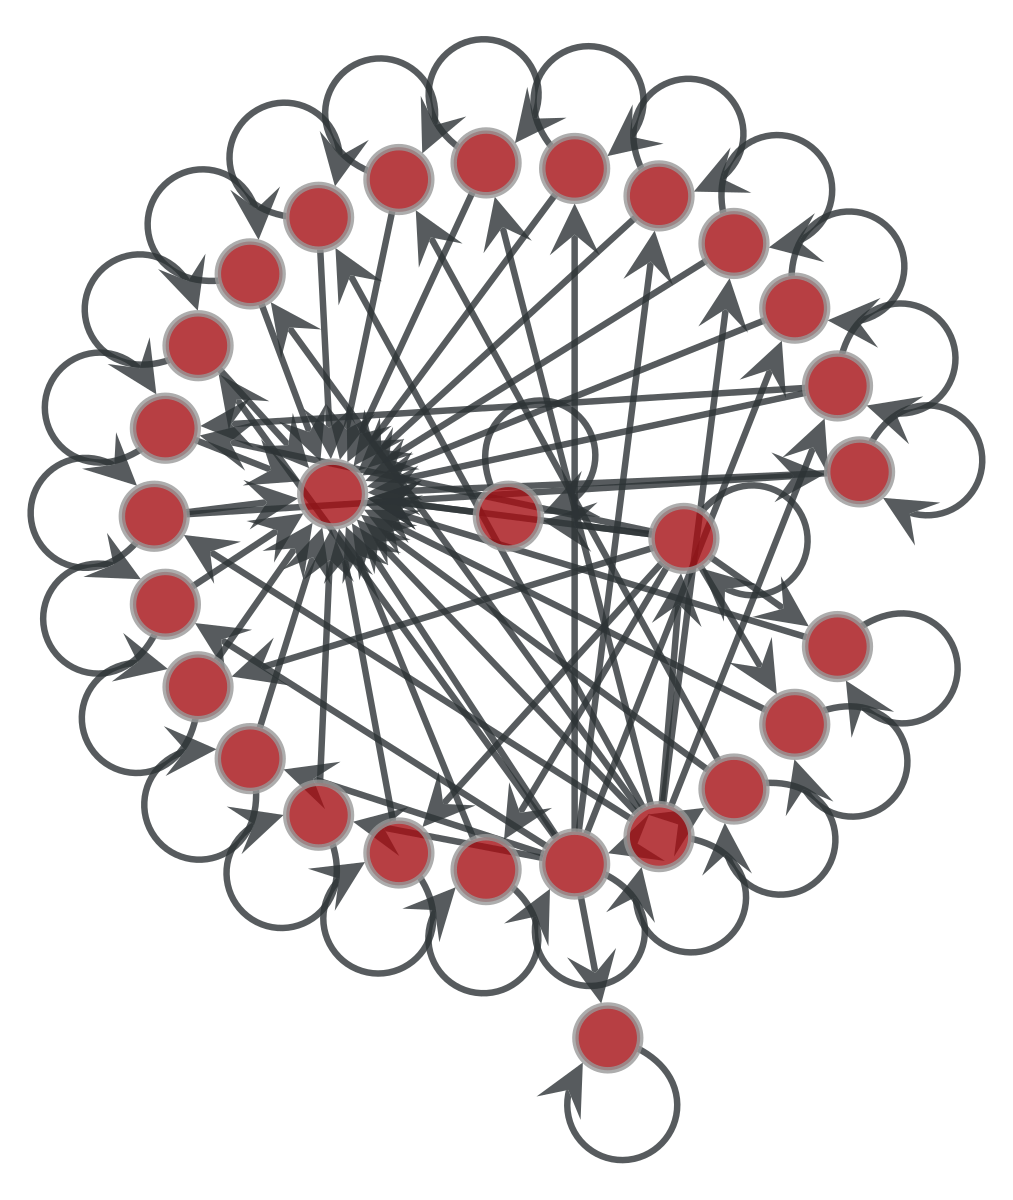

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fddc5829a90, at 0x7fddc5b6a9e0>

In [32]:
graph_draw(g_sub, pos=radial_tree_layout(g_sub, 0))

## Paths

In [21]:
def get_nodes_path(path):
    sequence_mut = [get_state(int(i))['mut'].values[0] for i in path]
    sequence_type = [get_state(int(i))['type'].values[0] for i in path]
    ch_mut = []
    ch_type = []
    for i in range(len(sequence_mut)):
        ch_mut.append([])
        ch_type.append([])
        for k in range(len((sequence_mut[i]).split("/"))):
            ch_mut[-1].append([int(s) for s in (sequence_mut[i]).split("/")[k]])
            ch_type[-1].append([int(s) for s in (sequence_type[i]).split("/")[k]])
    try:
        ch_mut = np.array(ch_mut)
        ch_type = np.array(ch_type)
    except:
        None
    return ch_type, ch_mut

In [35]:
#nodes_in_path = [int(s) for s in shortest_path(g,g.vertex(pert_state),g.vertex(538))[0]]
ppp = all_paths(g,g.vertex(pert_state),g.vertex(886))
nodes_in_path = [p for p in ppp]
ch_type_1, ch_mut_1 = get_nodes_path(nodes_in_path[1])
ch_type_0, ch_mut_0 = get_nodes_path(nodes_in_path[2])

In [32]:
mat = np.zeros([len(nodes_in_path), len(nodes_in_path)])
for i in range(len(nodes_in_path)):
    for j in range(len(nodes_in_path)):
        ch_type_1, ch_mut_1 = get_nodes_path(nodes_in_path[i])
        ch_type_0, ch_mut_0 = get_nodes_path(nodes_in_path[j])
        try:
            mat[i,j] = np.sum(ch_mut_0[:,1]-ch_mut_1[:,1])
        except:
            mat[i,j]=None

MemoryError: Unable to allocate 40.6 GiB for an array with shape (73855, 73855) and data type float64

In [ ]:
sns.heatmap(mat, center=0)

<Axes: >

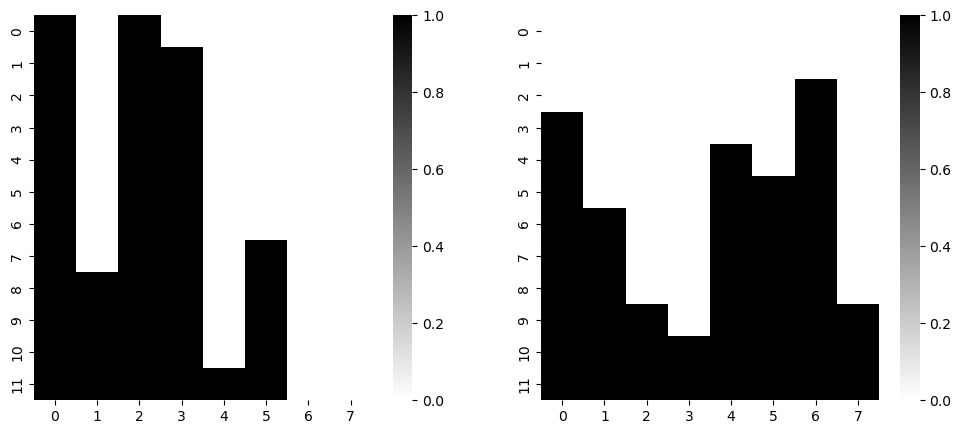

In [36]:
plt.subplots(1,2,figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(ch_mut_1[:,0], cmap="gray_r")
plt.subplot(1,2,2)
sns.heatmap(ch_mut_1[:,1], cmap="gray_r")

## Self Loops

In [27]:
self_loops = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    try:
        self_loops[i] = g.ep['w'][i,i]
    except:
        None

In [28]:
state_df['self_loops'] = state_df['idx'].map(lambda x: int(self_loops[x]))

In [29]:
state_df.sort_values('self_loops', ascending=False).head(10)

,idx,type,mut,nchr,ngenes,meanmut,pr,self_loops
361,361,11111111/11111111,00000000/00000000,2,16,0.0000,0.000291,18487153
524,524,11111111/11111111,10101000/10101001,2,16,0.4375,0.000276,87930
2790,2790,11111111/11111111,11111100/11011111,2,16,0.8125,0.000295,77957
886,886,11111111/11111111,11111100/11111111,2,16,0.8750,0.000291,75031
1330,1330,11111111/11111111,10100000/10011001,2,16,0.3750,0.000277,54391
336,336,11111111/11111111,11111111/11111100,2,16,0.8750,0.000298,50555
1738,1738,11111111/11111111,11111001/11011100,2,16,0.6875,0.000280,50369
867,867,11111111/11111111,10111001/10101100,2,16,0.5625,0.000289,46886
872,872,11111111/11111111,11111100/11011011,2,16,0.7500,0.000309,43322
1597,1597,11111111/11111111,11111100/11001111,2,16,0.7500,0.000286,43085


In [30]:
state_df.sort_values('pr', ascending=False).head(10)

,idx,type,mut,nchr,ngenes,meanmut,pr,self_loops
4741,4741,66666,11111,1,30,1.0000,0.093812,0
3113,3113,11111111/11111111,10101011/11101000,2,16,0.5625,0.000512,130
1935,1935,11111111/11111111,11010001/01111110,2,16,0.6250,0.000505,453
3464,3464,11111111/11111111,10101110/11111000,2,16,0.6250,0.000479,21
1792,1792,11111111/11111111,10111101/11000010,2,16,0.5625,0.000478,481
133,133,11111111/11111111,11111110/10001100,2,16,0.6250,0.000474,105
258,258,11111111/11111111,10110100/01011001,2,16,0.5000,0.000473,3004
1751,1751,11111111/11111111,10110001/11010110,2,16,0.5625,0.000470,47
747,747,11111111/11111111,11000101/11111010,2,16,0.6250,0.000450,377
229,229,11111111/11111111,10111000/11011011,2,16,0.6250,0.000425,12907


## Death state

In [37]:
death_route = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    try:
        death_route[i] = int(g.ep['w'][i,dead_state])
    except:
        None

In [38]:
w_out_edges = np.array([sum([g.ep['w'][e] for e in g.vertex(i).out_edges()]) for i in range(g.num_vertices())])

/tmp/ipykernel_114077/2070461932.py:1: RuntimeWarning: invalid value encountered in divide
  finish_death = death_route/w_out_edges


(array([2.919e+03, 1.260e+02, 5.400e+01, 2.200e+01, 1.000e+00, 2.000e+01,
        7.000e+00, 6.000e+00, 1.800e+01, 1.568e+03]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

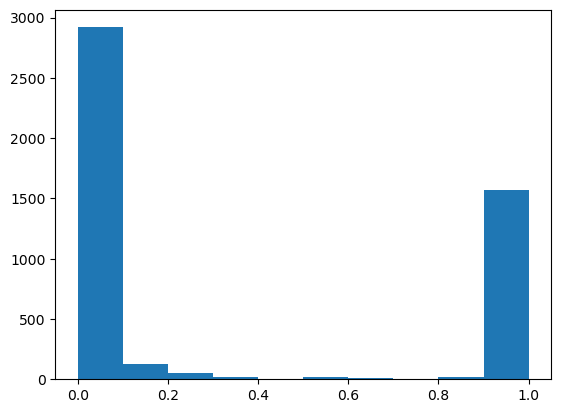

In [39]:
finish_death = death_route/w_out_edges
sss = np.argsort(finish_death)
plt.hist(finish_death)

## Community detection

In [40]:
state = minimize_blockmodel_dl(g)

In [41]:
state

<BlockState object with 4743 blocks (28 nonempty), degree-corrected, for graph <Graph object, directed, with 4743 vertices and 16393 edges, 3 internal vertex properties, 1 internal edge property, at 0x7f5ae9d29400>, at 0x7f5ad3d75160>

In [ ]:
state.draw()

In [ ]:
b_prop = state.b.a
groups = np.unique(b_prop)

In [ ]:
nodes_b = [np.where(b_prop==gi)[0] for gi in groups]

In [ ]:
nodes_b[3].shape

In [ ]:
i=0
for b, nb in zip(groups, nodes_b):
    print(b, nb.shape[0],i)
    i+=1

In [ ]:
in_deg[19617]

In [ ]:
get_state(nodes_b[36])